In [ ]:
# Customer Transaction Analysis

## Project Overview
This project analyzes a sample dataset of customer banking transactions to identify spending patterns, high-value customers, and potentially suspicious transactions.

## Tools Used
- Python
- Pandas
- NumPy
- Jupyter Notebook

## Key Questions
1. Which customers have the highest total transaction amounts?
2. What transaction categories move the most money?
3. Are there any unusually large transactions that may require review?
4. How do transaction amounts change over time?

In [1]:
import pandas as pd 
import numpy as np

data = {
    "Customer_ID": [101,102,103,101,104,102,103,105],
    "Transaction_Type": ["Deposit","Withdrawal","Deposit","Withdrawal","Deposit","Deposit","Withdrawal","Deposit"],
    "Amount": [500,200,800,150,1200,700,100,900]
}

df = pd.DataFrame(data)

df

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Customer_ID       8 non-null      int64 
 1   Transaction_Type  8 non-null      object
 2   Amount            8 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 324.0+ bytes


In [4]:
df.describe()

,Customer_ID,Amount
count,8.000000,8.000000
mean,102.625000,568.750000
std,1.407886,399.050212
min,101.000000,100.000000
25%,101.750000,187.500000
50%,102.500000,600.000000
75%,103.250000,825.000000
max,105.000000,1200.000000


In [5]:
df.groupby("Customer_ID")["Amount"].sum()

Customer_ID
101     650
102     900
103     900
104    1200
105     900
Name: Amount, dtype: int64

In [6]:
high_transactions = df[df["Amount"] > 700]

high_transactions

,Customer_ID,Transaction_Type,Amount
2,103,Deposit,800
4,104,Deposit,1200
7,105,Deposit,900


In [7]:
customer_totals = df.groupby("Customer_ID")["Amount"].sum()

customer_totals

Customer_ID
101     650
102     900
103     900
104    1200
105     900
Name: Amount, dtype: int64

In [8]:
customer_totals.sort_values(ascending=False)

Customer_ID
104    1200
102     900
103     900
105     900
101     650
Name: Amount, dtype: int64

<Axes: title={'center': 'Total Transactions per Customer'}, xlabel='Customer_ID'>

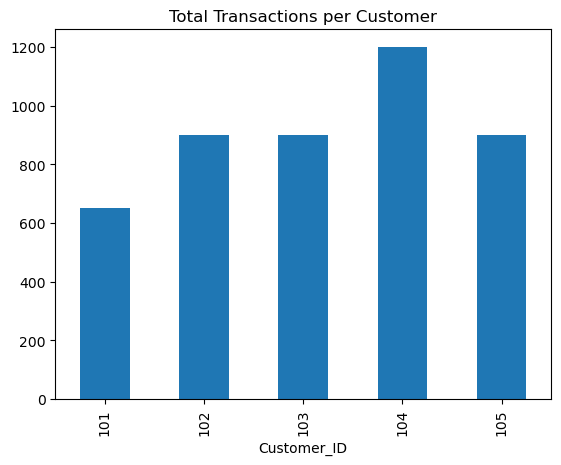

In [9]:
customer_totals.plot(kind="bar", title="Total Transactions per Customer")

In [10]:
df["Category"] = ["Salary", "ATM", "Salary", "Bills", "Business", "Salary", "ATM", "Investment"]

df

,Customer_ID,Transaction_Type,Amount,Category
0,101,Deposit,500,Salary
1,102,Withdrawal,200,ATM
2,103,Deposit,800,Salary
3,101,Withdrawal,150,Bills
4,104,Deposit,1200,Business
5,102,Deposit,700,Salary
6,103,Withdrawal,100,ATM
7,105,Deposit,900,Investment


In [11]:
df.groupby("Category")["Amount"].sum()

Category
ATM            300
Bills          150
Business      1200
Investment     900
Salary        2000
Name: Amount, dtype: int64

<Axes: title={'center': 'Transaction Amount by Category'}, xlabel='Category'>

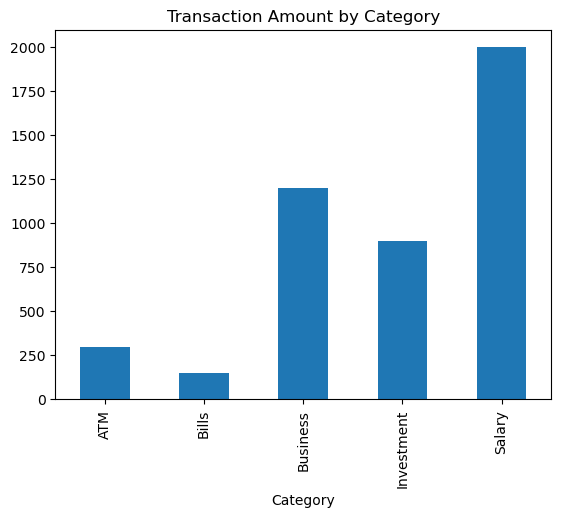

In [12]:
df.groupby("Category")["Amount"].sum().plot(kind="bar", title="Transaction Amount by Category")

In [13]:
df["Suspicious"] = df["Amount"] > 1000

df

,Customer_ID,Transaction_Type,Amount,Category,Suspicious
0,101,Deposit,500,Salary,False
1,102,Withdrawal,200,ATM,False
2,103,Deposit,800,Salary,False
3,101,Withdrawal,150,Bills,False
4,104,Deposit,1200,Business,True
5,102,Deposit,700,Salary,False
6,103,Withdrawal,100,ATM,False
7,105,Deposit,900,Investment,False


In [14]:
df[df["Suspicious"] == True]

,Customer_ID,Transaction_Type,Amount,Category,Suspicious
4,104,Deposit,1200,Business,True


In [16]:
df.to_csv("transactions.csv", index=False)

In [17]:
transactions = pd.read_csv("transactions.csv")

transactions.head()

,Customer_ID,Transaction_Type,Amount,Category,Suspicious
0,101,Deposit,500,Salary,False
1,102,Withdrawal,200,ATM,False
2,103,Deposit,800,Salary,False
3,101,Withdrawal,150,Bills,False
4,104,Deposit,1200,Business,True


In [18]:
top_customers = transactions.groupby("Customer_ID")["Amount"].sum().sort_values(ascending=False)

top_customers

Customer_ID
104    1200
102     900
103     900
105     900
101     650
Name: Amount, dtype: int64

<Axes: title={'center': 'Top Customers by Transaction Value'}, xlabel='Customer_ID'>

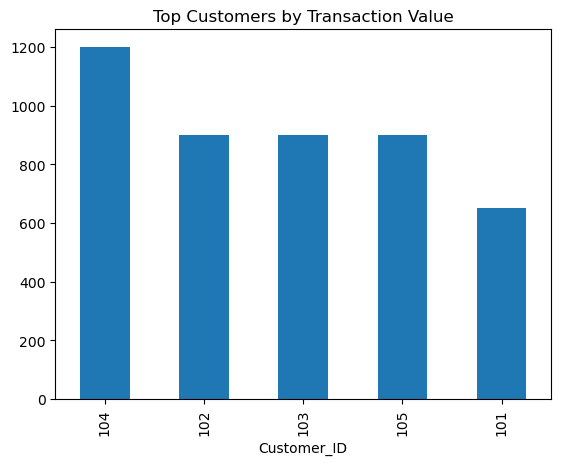

In [19]:
top_customers.plot(kind="bar", title="Top Customers by Transaction Value")

In [20]:
df["Date"] = pd.date_range(start="2024-01-01", periods=len(df), freq="D")

df

,Customer_ID,Transaction_Type,Amount,Category,Suspicious,Date
0,101,Deposit,500,Salary,False,2024-01-01
1,102,Withdrawal,200,ATM,False,2024-01-02
2,103,Deposit,800,Salary,False,2024-01-03
3,101,Withdrawal,150,Bills,False,2024-01-04
4,104,Deposit,1200,Business,True,2024-01-05
5,102,Deposit,700,Salary,False,2024-01-06
6,103,Withdrawal,100,ATM,False,2024-01-07
7,105,Deposit,900,Investment,False,2024-01-08


In [21]:
daily_transactions = df.groupby("Date")["Amount"].sum()

daily_transactions

Date
2024-01-01     500
2024-01-02     200
2024-01-03     800
2024-01-04     150
2024-01-05    1200
2024-01-06     700
2024-01-07     100
2024-01-08     900
Name: Amount, dtype: int64

<Axes: title={'center': 'Daily Transaction Amounts'}, xlabel='Date'>

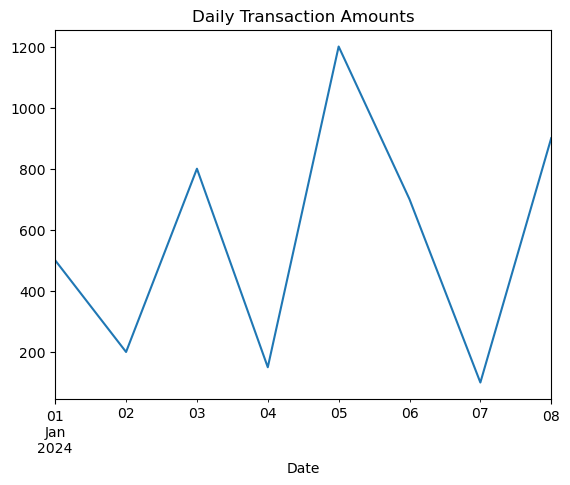

In [22]:
daily_transactions.plot(title="Daily Transaction Amounts")

In [23]:
df.groupby("Customer_ID")["Amount"].sum().sort_values(ascending=False)

Customer_ID
104    1200
102     900
103     900
105     900
101     650
Name: Amount, dtype: int64

In [24]:
df["Customer_ID"].value_counts()

Customer_ID
101    2
102    2
103    2
104    1
105    1
Name: count, dtype: int64

# Customer Transaction Analysis

## Project Overview
This project analyzes a sample dataset of customer banking transactions to identify spending patterns, high-value customers, and potentially suspicious transactions.

## Tools Used
- Python
- Pandas
- NumPy
- Jupyter Notebook

## Key Questions
1. Which customers have the highest total transaction amounts?
2. What transaction categories move the most money?
3. Are there any unusually large transactions that may require review?
4. How do transaction amounts change over time?

## Key Insights

- Customer 104 had the highest transaction amount in the dataset.
- Salary deposits accounted for the largest portion of total funds.
- One transaction exceeded $1000 and was flagged as potentially suspicious.
- Transaction amounts varied across customers and categories, showing different usage patterns.

## Conclusion

This analysis demonstrates how transaction data can be used to identify high-value customers, categorize spending behavior, and flag unusual financial activity.